<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangGraph(Part_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 2.2 MB/s eta 0:00:00


In [2]:
import operator

from IPython.display import Image
from google.colab import userdata
from langchain.agents import AgentState
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.runnables import RunnablePassthrough
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.types import Runnable
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import SecretStr
from typing import Annotated, List, Literal, TypedDict

openai_api_key = SecretStr(userdata.get("OPENAI_API_KEY"))

def print_conversation(conversation: List[BaseMessage]):
    for message in conversation:
        message.pretty_print()

def display_graph(runnable: Runnable, output_png: Path) -> None:
    graph = runnable.get_graph()

    with output_png.open(mode = "wb") as file:
        file.write(graph.draw_mermaid_png())

    display(Image(output_png, format="png"))

In [4]:
@tool
def weather(city: str) -> str:
    """Return a (fake) current-weather report for a city."""
    data = {
        "sofia": "Sofia: 18 C, partly cloudy",
        "london": "London: 11 C, rainy",
        "tokyo": "Tokyo: 22 C, sunny"
    }

    return data.get(city.lower(), f"No data for {city}.")

@tool
def search(query: str) -> str:
    """Look up a term in the built-in mini-encyclopedia."""
    data = {
        "langgraph": "LangGraph is a library for building stateful, cyclic LLM apps",
        "react": "ReAct is a prompting pattern: Reason then Act, in a loop.",
        "dag": "A DAG is a directed acyclic graph - no cycles allowed."
    }
    return data.get(query.lower(), "(nothing found)")

SYSTEM_PROMPT = "You are a concise assistant. Use tools when useful."
TOOLS = [weather, search]

In [8]:
model = ChatOpenAI(model="gpt-5-nano", api_key = openai_api_key).bind_tools(TOOLS) # .bind_tools(TOOLS) защото създаваме агента от нулата

class CustomAgentState(AgentState):
    model_calls: int


def model_node(state: CustomAgentState):
    response = model.invoke([SystemMessage(SYSTEM_PROMPT),*state["messages"]])
    return { "messages": [response] }

In [11]:
def has_pending_tool_calls(state: CustomAgentState) -> bool:
    messages = state.get("messages", [])

    if not messages:
        return False

    last_message = messages[-1]

    return isinstance(last_message, AIMessage) and last_message.tool_calls

In [12]:
graph_builder = StateGraph(CustomAgentState)

graph_builder.add_node("model", model_node)
graph_builder.add_node("tools", ToolNode(TOOLS))

graph_builder.add_edge(START,"model")
graph_builder.add_conditional_edges("model", lambda state: "tools" if has_pending_tool_calls(state) else END, ["tools", END])
graph_builder.add_edge("tools", "model")

graph = graph_builder.compile()

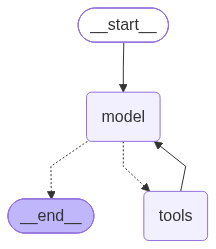

In [13]:
display_graph(graph, Path("/content/graph.png"))

In [14]:
final_state = graph.invoke(
    input = {
        "messages": [HumanMessage("What's the weather in Tokyo and what is LangGraph, briefly?")]
    }
)

In [15]:
print_conversation(final_state["messages"])

================================ Human Message =================================

What's the weather in Tokyo and what is LangGraph, briefly?
================================== Ai Message ==================================
Tool Calls:
  weather (call_qve98Gsr48tpQQ16vnzPaKbO)
 Call ID: call_qve98Gsr48tpQQ16vnzPaKbO
  Args:
    city: Tokyo
  search (call_N8ViNW8jfkdCwUl3hKauFZJZ)
 Call ID: call_N8ViNW8jfkdCwUl3hKauFZJZ
  Args:
    query: LangGraph
================================= Tool Message =================================
Name: weather

Tokyo: 22 C, sunny
================================= Tool Message =================================
Name: search

LangGraph is a library for building stateful, cyclic LLM apps
================================== Ai Message ==================================

- Tokyo: 22°C, sunny
- LangGraph: A library for building stateful, cyclic LLM applications.


In [16]:
final_state

{'messages': [HumanMessage(content="What's the weather in Tokyo and what is LangGraph, briefly?", additional_kwargs={}, response_metadata={}, id='87c6f7cd-3148-4c55-b0cc-d4070268dd9b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 372, 'prompt_tokens': 183, 'total_tokens': 555, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EJy2etx3tcTnqz9oNuWBwLLQVoVyv', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06699-9e24-7343-8fec-f10dd7dd41b1-0', tool_calls=[{'name': 'weather', 'args': {'city': 'Tokyo'}, 'id': 'call_qve98Gsr48tpQQ16vnzPaKbO', 'type': 'tool_call'}, {'name': 'search', '